# Spline Safety Verification

This notebook builds a small PyDrake demo for a planar B-spline trajectory. The trajectory is planned in `(x, y)`, then lifted to `(x, y, t)` for visualization. It shows:

- the B-spline curve,
- the convex hull induced by the B-spline control points,
- example unsafe convex regions,
- separating decision boundaries obtained with Drake's `MathematicalProgram`.

The core safety fact used here is the convex-hull property: a B-spline curve lies inside the convex hull of its control points. If a hyperplane separates that hull from an unsafe convex set, then it separates the entire spline from that unsafe set.

## Imports

In [1]:
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

try:
    from scipy.spatial import ConvexHull
except ImportError:
    ConvexHull = None

from pydrake.math import BsplineBasis
from pydrake.solvers import MathematicalProgram, Solve
from pydrake.trajectories import BsplineTrajectory

# Optional: point PyDrake/MOSEK at the common local license path when present.
mosek_license = os.path.join(os.path.expanduser("~"), "mosek", "mosek.lic")
if os.path.exists(mosek_license):
    os.environ.setdefault("MOSEKLM_LICENSE_FILE", mosek_license)

plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Helpers

In [2]:
def clamped_uniform_knots(num_control_points, degree, t0=0.0, tf=1.0):
    """Return an open/clamped uniform knot vector for a B-spline basis."""
    order = degree + 1
    if num_control_points < order:
        raise ValueError("num_control_points must be at least degree + 1")

    num_internal = num_control_points - order
    if num_internal > 0:
        internal = np.linspace(t0, tf, num_internal + 2)[1:-1]
    else:
        internal = np.array([])
    return np.r_[np.full(order, t0), internal, np.full(order, tf)]


def clamped_knots_from_breaks(breaks, degree):
    """Return an open/clamped knot vector from possibly nonuniform breaks."""
    breaks = np.asarray(breaks, dtype=float)
    if breaks.ndim != 1 or len(breaks) < 2:
        raise ValueError("breaks must be a 1D array with at least a start and end time")
    if np.any(np.diff(breaks) <= 0):
        raise ValueError("breaks must be strictly increasing")

    order = degree + 1
    return np.r_[np.full(order, breaks[0]), breaks[1:-1], np.full(order, breaks[-1])]


def greville_abscissae(knots, degree):
    """Representative parameter value for each B-spline control point."""
    if degree == 0:
        return np.asarray(knots[:-1], dtype=float)
    return np.array([
        np.mean(knots[i + 1 : i + degree + 1])
        for i in range(len(knots) - degree - 1)
    ])


def knot_span_control_point_indices(knots, degree):
    """Return active control-point indices for each nonzero B-spline knot span."""
    knots = np.asarray(knots, dtype=float)
    num_control_points = len(knots) - degree - 1
    spans = []
    for span_index in range(degree, num_control_points):
        t_start = knots[span_index]
        t_end = knots[span_index + 1]
        if t_end <= t_start:
            continue
        indices = np.arange(span_index - degree, span_index + 1, dtype=int)
        spans.append({
            "span_index": span_index,
            "t_start": float(t_start),
            "t_end": float(t_end),
            "indices": indices,
        })
    return spans


def make_bspline(control_points, degree=3, t0=0.0, tf=1.0, knots=None):
    """Construct a PyDrake BsplineTrajectory from row-wise control points."""
    control_points = np.asarray(control_points, dtype=float)
    if knots is None:
        knots = clamped_uniform_knots(len(control_points), degree, t0, tf)
    else:
        knots = np.asarray(knots, dtype=float)
        expected_num_knots = len(control_points) + degree + 1
        if len(knots) != expected_num_knots:
            raise ValueError(f"expected {expected_num_knots} knots, got {len(knots)}")
    basis = BsplineBasis(degree + 1, knots)
    drake_control_points = [p.reshape((-1, 1)) for p in control_points]
    trajectory = BsplineTrajectory(basis, drake_control_points)
    return trajectory, knots


def evaluate_trajectory(trajectory, ts):
    """Evaluate a Drake vector-valued trajectory into an array with shape (N, dim)."""
    return np.vstack([np.asarray(trajectory.value(float(t))).reshape(-1) for t in ts])


def convex_hull_2d(points):
    """Return hull vertices ordered around a 2D point set."""
    points = np.asarray(points, dtype=float)
    if ConvexHull is not None:
        return points[ConvexHull(points).vertices]

    # Monotone-chain fallback for environments without scipy.
    pts = sorted(map(tuple, points))
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return np.asarray(lower[:-1] + upper[:-1], dtype=float)


def rectangle_vertices(center, half_widths):
    cx, cy = center
    hx, hy = half_widths
    return np.array([
        [cx - hx, cy - hy],
        [cx + hx, cy - hy],
        [cx + hx, cy + hy],
        [cx - hx, cy + hy],
    ])


@dataclass
class DecisionBoundary:
    normal: np.ndarray
    offset: float
    solver_name: str

    def signed_distance_numerator(self, points):
        return np.asarray(points) @ self.normal - self.offset


def solve_separating_boundary(safe_hull_vertices, unsafe_vertices):
    """Fit a hard-margin linear separator using Drake's convex QP machinery.

    The safe hull is constrained to normal.T @ x - offset <= -1, and the
    unsafe set is constrained to normal.T @ x - offset >= +1. Because both
    sets are convex polytopes, constraining only their vertices is sufficient.
    """
    prog = MathematicalProgram()
    normal = prog.NewContinuousVariables(2, "normal")
    offset = prog.NewContinuousVariables(1, "offset")[0]

    for point in safe_hull_vertices:
        prog.AddLinearConstraint(point @ normal - offset <= -1.0)
    for point in unsafe_vertices:
        prog.AddLinearConstraint(point @ normal - offset >= 1.0)

    # The margin constraints fix scale; minimizing ||normal|| maximizes margin.
    prog.AddQuadraticCost(normal @ normal)
    result = Solve(prog)
    if not result.is_success():
        raise RuntimeError(f"No separating hyperplane found: {result.get_solution_result()}")

    return DecisionBoundary(
        normal=result.GetSolution(normal),
        offset=float(result.GetSolution(offset)),
        solver_name=result.get_solver_id().name(),
    )

## Define A Planar B-Spline

In [3]:
degree = 3
t0, tf = 0.0, 6.0

# Nonuniform parameter breaks. For 7 control points and a cubic B-spline,
# Drake expects 3 interior knots, so this gives a nonuniform clamped knot vector.
knot_breaks = np.array([t0, 0.65, 2.25, 4.85, tf])
knots = clamped_knots_from_breaks(knot_breaks, degree)

# Row-wise planar control points. Edit these to change the trajectory shape.
control_points_xy = np.array([
    [0.0, 0.0],
    [0.8, 0.6],
    [1.7, 0.9],
    [2.7, 0.55],
    [3.6, 0.15],
    [4.6, 0.45],
    [5.4, 1.0],
])

trajectory_xy, knots = make_bspline(control_points_xy, degree=degree, knots=knots)
ts = np.linspace(t0, tf, 300)
curve_xy = evaluate_trajectory(trajectory_xy, ts)

# These are intentionally nonuniform. With Greville abscissae, the lifted
# coordinate z(t) is the identity time parameter for this same B-spline basis.
control_times = greville_abscissae(knots, degree)
control_points_xyt = np.c_[control_points_xy, control_times]
trajectory_xyt, _ = make_bspline(control_points_xyt, degree=degree, knots=knots)
curve_xyt = evaluate_trajectory(trajectory_xyt, ts)

safe_hull_xy = convex_hull_2d(control_points_xy)
print(f"Constructed a degree-{degree} B-spline with {len(control_points_xy)} control points.")
print(f"Nonuniform knot breaks: {knot_breaks}")
print(f"Full clamped knot vector: {knots}")
print(f"Lifted control-point time coordinates: {control_times.round(3)}")
print(f"Control-time spacings: {np.diff(control_times).round(3)}")
print(f"The spline is evaluated on t in [{t0}, {tf}].")
print(f"Max |lifted spline time coordinate - parameter|: {np.max(np.abs(curve_xyt[:, 2] - ts)):.2e}")

Constructed a degree-3 B-spline with 7 control points.
Nonuniform knot breaks: [0.   0.65 2.25 4.85 6.  ]
Full clamped knot vector: [0.   0.   0.   0.   0.65 2.25 4.85 6.   6.   6.   6.  ]
Lifted control-point time coordinates: [0.    0.217 0.967 2.583 4.367 5.617 6.   ]
Control-time spacings: [0.217 0.75  1.617 1.783 1.25  0.383]
The spline is evaluated on t in [0.0, 6.0].
Max |lifted spline time coordinate - parameter|: 1.78e-15


## Unsafe Sets And Decision Boundaries

In [4]:
# Example convex unsafe regions. They are intentionally placed outside the
# control-point hull so a linear certificate exists.
unsafe_sets = {
    "upper obstacle": rectangle_vertices(center=(2.55, 1.85), half_widths=(0.65, 0.35)),
    "lower obstacle": rectangle_vertices(center=(3.65, -0.85), half_widths=(0.55, 0.30)),
}

boundaries = {
    name: solve_separating_boundary(safe_hull_xy, vertices)
    for name, vertices in unsafe_sets.items()
}

for name, boundary in boundaries.items():
    print(f"{name}: normal={boundary.normal.round(3)}, offset={boundary.offset:.3f}, solver={boundary.solver_name}")
    print(f"  max safe signed value: {boundary.signed_distance_numerator(safe_hull_xy).max():.3f}")
    print(f"  min unsafe signed value: {boundary.signed_distance_numerator(unsafe_sets[name]).min():.3f}")

upper obstacle: normal=[-0.097  3.575], offset=4.053, solver=Mosek
  max safe signed value: -1.000
  min unsafe signed value: 1.000
lower obstacle: normal=[ 0.123 -2.945], offset=1.000, solver=Mosek
  max safe signed value: -1.000
  min unsafe signed value: 1.000


## 2D View

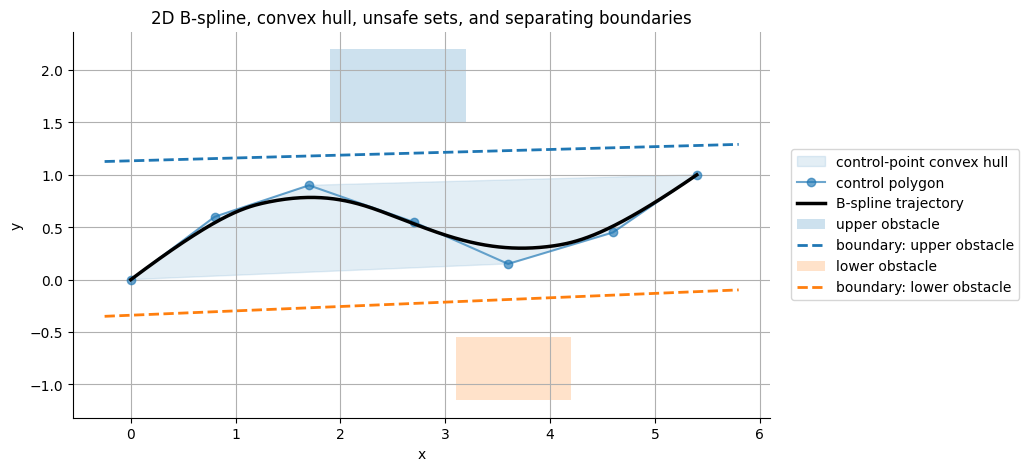

In [5]:
def plot_boundary_2d(ax, boundary, x_limits, label):
    normal = boundary.normal
    x_values = np.linspace(x_limits[0], x_limits[1], 100)
    if abs(normal[1]) > 1e-9:
        y_values = (boundary.offset - normal[0] * x_values) / normal[1]
        ax.plot(x_values, y_values, "--", linewidth=2, label=label)
    else:
        ax.axvline(boundary.offset / normal[0], linestyle="--", linewidth=2, label=label)


fig, ax = plt.subplots(figsize=(9, 6))
hull_closed = np.r_[safe_hull_xy, safe_hull_xy[:1]]
ax.fill(hull_closed[:, 0], hull_closed[:, 1], color="tab:blue", alpha=0.12, label="control-point convex hull")
ax.plot(control_points_xy[:, 0], control_points_xy[:, 1], "o-", color="tab:blue", alpha=0.65, label="control polygon")
ax.plot(curve_xy[:, 0], curve_xy[:, 1], color="black", linewidth=2.5, label="B-spline trajectory")

for name, vertices in unsafe_sets.items():
    closed = np.r_[vertices, vertices[:1]]
    ax.fill(closed[:, 0], closed[:, 1], alpha=0.22, label=name)
    plot_boundary_2d(ax, boundaries[name], x_limits=(-0.25, 5.8), label=f"boundary: {name}")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D B-spline, convex hull, unsafe sets, and separating boundaries")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

## Knot-Span Bounding Polygons

The global control-point hull is conservative. On each nonzero knot span, a degree-`p` B-spline segment is contained in the convex hull of only the `p + 1` active control points for that span.

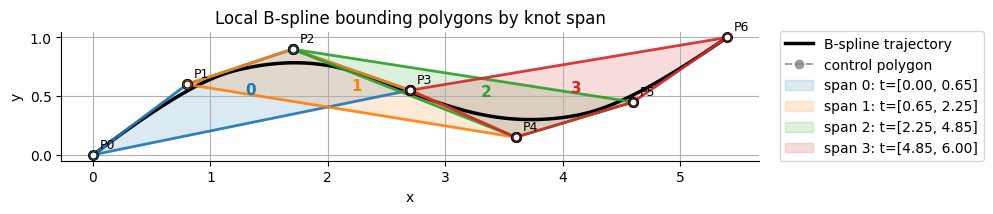

span 0: t=[0.00, 0.65] uses control points P0, P1, P2, P3
span 1: t=[0.65, 2.25] uses control points P1, P2, P3, P4
span 2: t=[2.25, 4.85] uses control points P2, P3, P4, P5
span 3: t=[4.85, 6.00] uses control points P3, P4, P5, P6


In [6]:
local_knot_spans = knot_span_control_point_indices(knots, degree)
span_colors = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(curve_xy[:, 0], curve_xy[:, 1], color="black", linewidth=2.5, label="B-spline trajectory")
ax.plot(
    control_points_xy[:, 0],
    control_points_xy[:, 1],
    "o--",
    color="tab:gray",
    alpha=0.72,
    linewidth=1.4,
    label="control polygon",
)

for span_number, span in enumerate(local_knot_spans):
    active_indices = span["indices"]
    active_points = control_points_xy[active_indices]
    hull = convex_hull_2d(active_points)
    closed = np.r_[hull, hull[:1]]
    color = span_colors(span_number % 10)
    label = f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}]"
    ax.fill(closed[:, 0], closed[:, 1], color=color, alpha=0.16, label=label)
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=2.0, alpha=0.9)
    ax.scatter(
        active_points[:, 0],
        active_points[:, 1],
        s=52,
        color=[color],
        edgecolor="black",
        linewidth=0.65,
        zorder=4,
    )
    centroid = hull.mean(axis=0)
    ax.text(centroid[0], centroid[1], str(span_number), color=color, fontsize=11, weight="bold")

ax.scatter(
    control_points_xy[:, 0],
    control_points_xy[:, 1],
    s=26,
    color="white",
    edgecolor="black",
    linewidth=0.75,
    zorder=5,
)
for idx, point in enumerate(control_points_xy):
    ax.annotate(f"P{idx}", point, xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Local B-spline bounding polygons by knot span")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

for span_number, span in enumerate(local_knot_spans):
    active_labels = ", ".join(f"P{i}" for i in span["indices"])
    print(
        f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}] "
        f"uses control points {active_labels}"
    )


## Interactive Knot-Span Bounding Polygons

This Plotly view pairs each local convex hull with the sampled spline segment from the same knot span.

In [7]:
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive knot-span view, for example: pip install plotly"
    ) from exc


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    red = int(hex_color[0:2], 16)
    green = int(hex_color[2:4], 16)
    blue = int(hex_color[4:6], 16)
    return f"rgba({red}, {green}, {blue}, {alpha})"


local_knot_spans = knot_span_control_point_indices(knots, degree)
plotly_span_colors = qualitative.Plotly

fig = go.Figure()

for span_number, span in enumerate(local_knot_spans):
    active_indices = span["indices"]
    active_points = control_points_xy[active_indices]
    hull = convex_hull_2d(active_points)
    closed = np.r_[hull, hull[:1]]
    color = plotly_span_colors[span_number % len(plotly_span_colors)]
    label = f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}]"

    fig.add_trace(go.Scatter(
        x=closed[:, 0],
        y=closed[:, 1],
        mode="lines",
        fill="toself",
        fillcolor=hex_to_rgba(color, 0.18),
        line=dict(color=color, width=2),
        name=f"hull {span_number}",
        text=[f"{label}<br>active: {', '.join(f'P{i}' for i in active_indices)}"] * len(closed),
        hovertemplate="%{text}<extra></extra>",
    ))

    if span_number == len(local_knot_spans) - 1:
        span_mask = (ts >= span["t_start"]) & (ts <= span["t_end"])
    else:
        span_mask = (ts >= span["t_start"]) & (ts < span["t_end"])
    segment_curve = curve_xy[span_mask]
    segment_t = ts[span_mask]
    fig.add_trace(go.Scatter(
        x=segment_curve[:, 0],
        y=segment_curve[:, 1],
        mode="lines",
        line=dict(color=color, width=4),
        name=f"curve {span_number}",
        customdata=segment_t,
        hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{customdata:.2f}<extra></extra>",
    ))

fig.add_trace(go.Scatter(
    x=control_points_xy[:, 0],
    y=control_points_xy[:, 1],
    mode="lines+markers+text",
    line=dict(color="darkgray", width=2, dash="dash"),
    marker=dict(size=8, color="white", line=dict(color="black", width=1)),
    text=[f"P{idx}" for idx in range(len(control_points_xy))],
    textposition="top center",
    name="control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive local B-spline bounding polygons by knot span",
    xaxis_title="x",
    yaxis_title="y",
    hovermode="closest",
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=1.02, y=1.0),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

## Interactive Knot-Span Bounding Polytopes In Time

This view lifts the local knot-span hulls into `(x, y, t)`, so each colored polytope bounds only the spline segment over the same time interval.

In [8]:
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive time-lifted knot-span view, for example: pip install plotly"
    ) from exc

if ConvexHull is None:
    raise ImportError("scipy is required to compute the local 3D convex hull faces for Plotly.")


def edges_from_simplices(simplices):
    edges = set()
    for simplex in simplices:
        for local_i in range(len(simplex)):
            for local_j in range(local_i + 1, len(simplex)):
                edges.add(tuple(sorted((int(simplex[local_i]), int(simplex[local_j])))))
    return sorted(edges)


local_knot_spans = knot_span_control_point_indices(knots, degree)
plotly_span_colors = qualitative.Plotly

fig = go.Figure()

for span_number, span in enumerate(local_knot_spans):
    active_indices = span["indices"]
    active_points = control_points_xyt[active_indices]
    hull = ConvexHull(active_points, qhull_options="QJ")
    hi, hj, hk = hull.simplices.T
    color = plotly_span_colors[span_number % len(plotly_span_colors)]
    label = f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}]"
    active_label = ", ".join(f"P{i}" for i in active_indices)

    fig.add_trace(go.Mesh3d(
        x=active_points[:, 0],
        y=active_points[:, 1],
        z=active_points[:, 2],
        i=hi,
        j=hj,
        k=hk,
        name=f"hull {span_number}",
        color=color,
        opacity=0.23,
        flatshading=True,
        hovertemplate=f"{label}<br>active: {active_label}<extra></extra>",
    ))

    for edge_number, (a, b) in enumerate(edges_from_simplices(hull.simplices)):
        edge = active_points[[a, b]]
        fig.add_trace(go.Scatter3d(
            x=edge[:, 0],
            y=edge[:, 1],
            z=edge[:, 2],
            mode="lines",
            line=dict(color=color, width=5),
            showlegend=False,
            hoverinfo="skip",
        ))

    if span_number == len(local_knot_spans) - 1:
        span_mask = (ts >= span["t_start"]) & (ts <= span["t_end"])
    else:
        span_mask = (ts >= span["t_start"]) & (ts < span["t_end"])
    segment_curve = curve_xyt[span_mask]
    fig.add_trace(go.Scatter3d(
        x=segment_curve[:, 0],
        y=segment_curve[:, 1],
        z=segment_curve[:, 2],
        mode="lines",
        line=dict(color=color, width=7),
        name=f"curve {span_number}",
        hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
    ))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    mode="lines+markers+text",
    line=dict(color="darkorange", width=4, dash="dash"),
    marker=dict(size=6, color="darkorange", line=dict(color="black", width=1)),
    text=[f"P{idx}" for idx in range(len(control_points_xyt))],
    textposition="top center",
    name="lifted control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive local B-spline bounding polytopes by knot span in (x, y, t)",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

## 3D Bounding Polytope

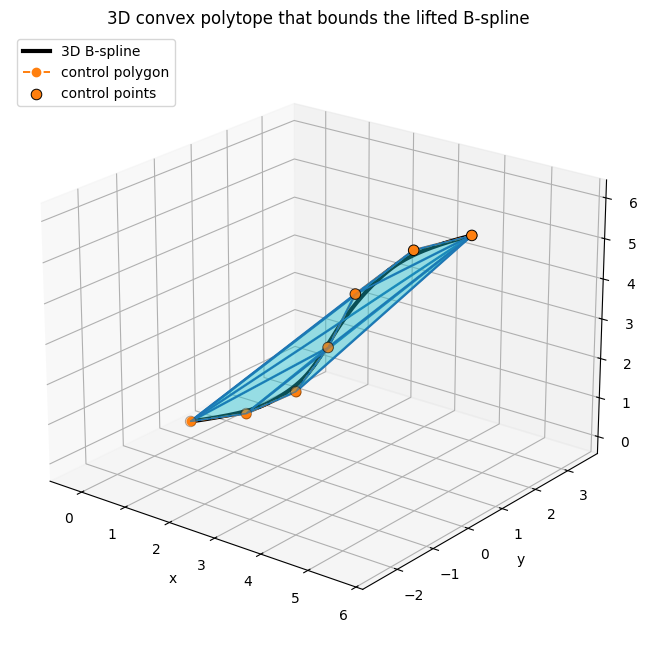

3D hull vertices: 7
3D hull triangular faces: 10
3D hull edges: 15


In [9]:
def set_axes_equal_3d(ax):
    """Make a 3D matplotlib axis use equal data scale on x, y, and z."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()], dtype=float)
    centers = limits.mean(axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d(centers[0] - radius, centers[0] + radius)
    ax.set_ylim3d(centers[1] - radius, centers[1] + radius)
    ax.set_zlim3d(centers[2] - radius, centers[2] + radius)


def hull_edges_from_simplices(simplices):
    edges = set()
    for simplex in simplices:
        for local_i in range(len(simplex)):
            for local_j in range(local_i + 1, len(simplex)):
                edges.add(tuple(sorted((int(simplex[local_i]), int(simplex[local_j])))))
    return sorted(edges)


if ConvexHull is None:
    raise ImportError("scipy is required to render the 3D convex hull faces. Install scipy or run this in the project kernel.")

polytope_hull = ConvexHull(control_points_xyt)
polytope_faces = [control_points_xyt[simplex] for simplex in polytope_hull.simplices]
polytope_edges = hull_edges_from_simplices(polytope_hull.simplices)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

face_collection = Poly3DCollection(
    polytope_faces,
    facecolor="tab:cyan",
    edgecolor="tab:blue",
    linewidth=0.9,
    alpha=0.24,
)
ax.add_collection3d(face_collection)

for i, j in polytope_edges:
    edge = control_points_xyt[[i, j]]
    ax.plot(edge[:, 0], edge[:, 1], edge[:, 2], color="tab:blue", linewidth=1.8, alpha=0.95)

ax.plot(curve_xyt[:, 0], curve_xyt[:, 1], curve_xyt[:, 2], color="black", linewidth=3.0, label="3D B-spline")
ax.plot(control_points_xyt[:, 0], control_points_xyt[:, 1], control_points_xyt[:, 2], "o--", color="tab:orange", linewidth=1.4, label="control polygon")
ax.scatter(
    control_points_xyt[:, 0],
    control_points_xyt[:, 1],
    control_points_xyt[:, 2],
    s=58,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.7,
    zorder=5,
    label="control points",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("t")
ax.set_title("3D convex polytope that bounds the lifted B-spline")
ax.view_init(elev=22, azim=-52)
ax.legend(loc="upper left")
set_axes_equal_3d(ax)
plt.show()

print(f"3D hull vertices: {len(polytope_hull.vertices)}")
print(f"3D hull triangular faces: {len(polytope_hull.simplices)}")
print(f"3D hull edges: {len(polytope_edges)}")

## Interactive 3D Bounding Polytope

In [10]:
try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive 3D view, for example: pip install plotly"
    ) from exc

if ConvexHull is None:
    raise ImportError("scipy is required to compute the 3D convex hull faces for Plotly.")

polytope_hull = ConvexHull(control_points_xyt)
i, j, k = polytope_hull.simplices.T

fig = go.Figure()
fig.add_trace(go.Mesh3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    i=i,
    j=j,
    k=k,
    name="bounding polytope",
    color="deepskyblue",
    opacity=0.28,
    flatshading=True,
    hovertemplate="polytope face<extra></extra>",
))

for edge_index, (a, b) in enumerate(hull_edges_from_simplices(polytope_hull.simplices)):
    edge = control_points_xyt[[a, b]]
    fig.add_trace(go.Scatter3d(
        x=edge[:, 0],
        y=edge[:, 1],
        z=edge[:, 2],
        mode="lines",
        line=dict(color="royalblue", width=5),
        showlegend=edge_index == 0,
        name="polytope edges",
        hoverinfo="skip",
    ))

fig.add_trace(go.Scatter3d(
    x=curve_xyt[:, 0],
    y=curve_xyt[:, 1],
    z=curve_xyt[:, 2],
    mode="lines",
    line=dict(color="black", width=7),
    name="3D B-spline",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    mode="lines+markers+text",
    line=dict(color="darkorange", width=4, dash="dash"),
    marker=dict(size=6, color="darkorange", line=dict(color="black", width=1)),
    text=[f"P{idx}" for idx in range(len(control_points_xyt))],
    textposition="top center",
    name="control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive 3D convex polytope bounding the B-spline",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

## Spiral Example

In [11]:
# A second trajectory whose planar control polygon winds around like a spiral.
# This usually produces a much more visibly volumetric 3D hull.
spiral_degree = 3
spiral_t0, spiral_tf = 0.0, 8.0
num_spiral_control_points = 12

theta = np.linspace(0.15, 2.85 * np.pi, num_spiral_control_points)
radius = np.linspace(0.35, 2.25, num_spiral_control_points)
control_points_xy_spiral = np.c_[
    radius * np.cos(theta),
    radius * np.sin(theta),
]

# For n control points and degree p, the full clamped knot vector needs
# n + p + 1 knots, so the break list needs n - p + 1 values.
spiral_interval_weights = np.array([0.45, 1.25, 0.7, 1.55, 0.9, 1.8, 0.6, 1.1, 0.75])
spiral_breaks = spiral_t0 + (spiral_tf - spiral_t0) * np.r_[0.0, np.cumsum(spiral_interval_weights)] / np.sum(spiral_interval_weights)
spiral_knots = clamped_knots_from_breaks(spiral_breaks, spiral_degree)
spiral_control_times = greville_abscissae(spiral_knots, spiral_degree)

control_points_xyt_spiral = np.c_[control_points_xy_spiral, spiral_control_times]
trajectory_xyt_spiral, _ = make_bspline(control_points_xyt_spiral, degree=spiral_degree, knots=spiral_knots)
spiral_ts = np.linspace(spiral_t0, spiral_tf, 450)
curve_xyt_spiral = evaluate_trajectory(trajectory_xyt_spiral, spiral_ts)

if ConvexHull is None:
    raise ImportError("scipy is required to compute the spiral 3D convex hull faces.")

spiral_hull = ConvexHull(control_points_xyt_spiral)
print(f"Spiral nonuniform knot breaks: {spiral_breaks.round(3)}")
print(f"Spiral lifted control times: {spiral_control_times.round(3)}")
print(f"Spiral control-time spacings: {np.diff(spiral_control_times).round(3)}")
print(f"Spiral hull volume: {spiral_hull.volume:.4f}")
print(f"Spiral hull triangular faces: {len(spiral_hull.simplices)}")

Spiral nonuniform knot breaks: [0.    0.396 1.495 2.11  3.473 4.264 5.846 6.374 7.341 8.   ]
Spiral lifted control times: [0.    0.132 0.63  1.333 2.359 3.282 4.527 5.495 6.52  7.238 7.78  8.   ]
Spiral control-time spacings: [0.132 0.498 0.703 1.026 0.923 1.245 0.967 1.026 0.718 0.542 0.22 ]
Spiral hull volume: 23.9841
Spiral hull triangular faces: 20


## Interactive Spiral Knot-Span Bounding Polygons

This Plotly view shows the spiral spline's local planar convex hulls, paired with the sampled curve segment from the same knot span.

In [12]:
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive spiral knot-span view, for example: pip install plotly"
    ) from exc


def spiral_hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    red = int(hex_color[0:2], 16)
    green = int(hex_color[2:4], 16)
    blue = int(hex_color[4:6], 16)
    return f"rgba({red}, {green}, {blue}, {alpha})"


spiral_local_knot_spans = knot_span_control_point_indices(spiral_knots, spiral_degree)
spiral_plotly_span_colors = qualitative.Plotly
curve_xy_spiral = curve_xyt_spiral[:, :2]

fig = go.Figure()

for span_number, span in enumerate(spiral_local_knot_spans):
    active_indices = span["indices"]
    active_points = control_points_xy_spiral[active_indices]
    hull = convex_hull_2d(active_points)
    closed = np.r_[hull, hull[:1]]
    color = spiral_plotly_span_colors[span_number % len(spiral_plotly_span_colors)]
    label = f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}]"
    active_label = ", ".join(f"S{i}" for i in active_indices)

    fig.add_trace(go.Scatter(
        x=closed[:, 0],
        y=closed[:, 1],
        mode="lines",
        fill="toself",
        fillcolor=spiral_hex_to_rgba(color, 0.18),
        line=dict(color=color, width=2),
        name=f"hull {span_number}",
        text=[f"{label}<br>active: {active_label}"] * len(closed),
        hovertemplate="%{text}<extra></extra>",
    ))

    if span_number == len(spiral_local_knot_spans) - 1:
        span_mask = (spiral_ts >= span["t_start"]) & (spiral_ts <= span["t_end"])
    else:
        span_mask = (spiral_ts >= span["t_start"]) & (spiral_ts < span["t_end"])
    segment_curve = curve_xy_spiral[span_mask]
    segment_t = spiral_ts[span_mask]
    fig.add_trace(go.Scatter(
        x=segment_curve[:, 0],
        y=segment_curve[:, 1],
        mode="lines",
        line=dict(color=color, width=4),
        name=f"curve {span_number}",
        customdata=segment_t,
        hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{customdata:.2f}<extra></extra>",
    ))

fig.add_trace(go.Scatter(
    x=control_points_xy_spiral[:, 0],
    y=control_points_xy_spiral[:, 1],
    mode="lines+markers+text",
    line=dict(color="darkgray", width=2, dash="dash"),
    marker=dict(size=8, color="white", line=dict(color="black", width=1)),
    text=[f"S{idx}" for idx in range(len(control_points_xy_spiral))],
    textposition="top center",
    name="spiral control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive spiral local B-spline bounding polygons by knot span",
    xaxis_title="x",
    yaxis_title="y",
    hovermode="closest",
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=1.02, y=1.0),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

## Interactive Spiral Knot-Span Bounding Polytopes In Time

This view lifts the spiral local knot-span hulls into `(x, y, t)`, so each colored polytope bounds only the spiral segment over the same time interval.

In [13]:
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive time-lifted spiral knot-span view, for example: pip install plotly"
    ) from exc

if ConvexHull is None:
    raise ImportError("scipy is required to compute the spiral local 3D convex hull faces for Plotly.")


def spiral_edges_from_simplices(simplices):
    edges = set()
    for simplex in simplices:
        for local_i in range(len(simplex)):
            for local_j in range(local_i + 1, len(simplex)):
                edges.add(tuple(sorted((int(simplex[local_i]), int(simplex[local_j])))))
    return sorted(edges)


spiral_local_knot_spans = knot_span_control_point_indices(spiral_knots, spiral_degree)
spiral_plotly_span_colors = qualitative.Plotly

fig = go.Figure()

for span_number, span in enumerate(spiral_local_knot_spans):
    active_indices = span["indices"]
    active_points = control_points_xyt_spiral[active_indices]
    hull = ConvexHull(active_points, qhull_options="QJ")
    hi, hj, hk = hull.simplices.T
    color = spiral_plotly_span_colors[span_number % len(spiral_plotly_span_colors)]
    label = f"span {span_number}: t=[{span['t_start']:.2f}, {span['t_end']:.2f}]"
    active_label = ", ".join(f"S{i}" for i in active_indices)

    fig.add_trace(go.Mesh3d(
        x=active_points[:, 0],
        y=active_points[:, 1],
        z=active_points[:, 2],
        i=hi,
        j=hj,
        k=hk,
        name=f"hull {span_number}",
        color=color,
        opacity=0.23,
        flatshading=True,
        hovertemplate=f"{label}<br>active: {active_label}<extra></extra>",
    ))

    for edge_number, (a, b) in enumerate(spiral_edges_from_simplices(hull.simplices)):
        edge = active_points[[a, b]]
        fig.add_trace(go.Scatter3d(
            x=edge[:, 0],
            y=edge[:, 1],
            z=edge[:, 2],
            mode="lines",
            line=dict(color=color, width=5),
            showlegend=False,
            hoverinfo="skip",
        ))

    if span_number == len(spiral_local_knot_spans) - 1:
        span_mask = (spiral_ts >= span["t_start"]) & (spiral_ts <= span["t_end"])
    else:
        span_mask = (spiral_ts >= span["t_start"]) & (spiral_ts < span["t_end"])
    segment_curve = curve_xyt_spiral[span_mask]
    fig.add_trace(go.Scatter3d(
        x=segment_curve[:, 0],
        y=segment_curve[:, 1],
        z=segment_curve[:, 2],
        mode="lines",
        line=dict(color=color, width=7),
        name=f"curve {span_number}",
        hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
    ))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt_spiral[:, 0],
    y=control_points_xyt_spiral[:, 1],
    z=control_points_xyt_spiral[:, 2],
    mode="lines+markers+text",
    line=dict(color="darkorange", width=4, dash="dash"),
    marker=dict(size=6, color="darkorange", line=dict(color="black", width=1)),
    text=[f"S{idx}" for idx in range(len(control_points_xyt_spiral))],
    textposition="top center",
    name="lifted spiral control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive spiral local B-spline bounding polytopes by knot span in (x, y, t)",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

In [14]:
try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "Install plotly to use the interactive spiral 3D view, for example: pip install plotly"
    ) from exc

si, sj, sk = spiral_hull.simplices.T
fig = go.Figure()
fig.add_trace(go.Mesh3d(
    x=control_points_xyt_spiral[:, 0],
    y=control_points_xyt_spiral[:, 1],
    z=control_points_xyt_spiral[:, 2],
    i=si,
    j=sj,
    k=sk,
    name="spiral bounding polytope",
    color="mediumseagreen",
    opacity=0.24,
    flatshading=True,
    hovertemplate="spiral polytope face<extra></extra>",
))

for edge_index, (a, b) in enumerate(hull_edges_from_simplices(spiral_hull.simplices)):
    edge = control_points_xyt_spiral[[a, b]]
    fig.add_trace(go.Scatter3d(
        x=edge[:, 0],
        y=edge[:, 1],
        z=edge[:, 2],
        mode="lines",
        line=dict(color="seagreen", width=5),
        showlegend=edge_index == 0,
        name="spiral hull edges",
        hoverinfo="skip",
    ))

fig.add_trace(go.Scatter3d(
    x=curve_xyt_spiral[:, 0],
    y=curve_xyt_spiral[:, 1],
    z=curve_xyt_spiral[:, 2],
    mode="lines",
    line=dict(color="black", width=7),
    name="spiral B-spline",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt_spiral[:, 0],
    y=control_points_xyt_spiral[:, 1],
    z=control_points_xyt_spiral[:, 2],
    mode="lines+markers+text",
    line=dict(color="darkorange", width=4, dash="dash"),
    marker=dict(size=6, color="darkorange", line=dict(color="black", width=1)),
    text=[f"S{idx}" for idx in range(len(control_points_xyt_spiral))],
    textposition="top center",
    name="spiral control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title="Interactive spiral B-spline and its 3D bounding polytope",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

## 3D Visualization

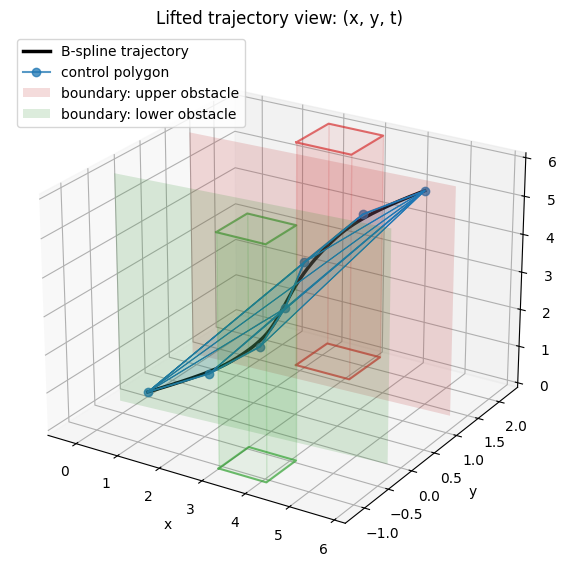

In [15]:
def add_convex_hull_3d(ax, points, color="tab:blue", alpha=0.12):
    if ConvexHull is None:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=color, alpha=0.45)
        return
    hull = ConvexHull(points)
    faces = [points[simplex] for simplex in hull.simplices]
    poly = Poly3DCollection(faces, facecolor=color, edgecolor=color, linewidth=0.8, alpha=alpha)
    ax.add_collection3d(poly)


def add_boundary_surface_3d(ax, boundary, x_limits, t_limits, color, label):
    normal = boundary.normal
    xs = np.linspace(x_limits[0], x_limits[1], 2)
    zs = np.linspace(t_limits[0], t_limits[1], 2)
    X, Z = np.meshgrid(xs, zs)
    if abs(normal[1]) > 1e-9:
        Y = (boundary.offset - normal[0] * X) / normal[1]
        ax.plot_surface(X, Y, Z, color=color, alpha=0.16, linewidth=0, label=label)
    else:
        X = np.full_like(X, boundary.offset / normal[0])
        Y, Z = np.meshgrid(np.linspace(-1.4, 2.4, 2), zs)
        ax.plot_surface(X, Y, Z, color=color, alpha=0.16, linewidth=0, label=label)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(curve_xyt[:, 0], curve_xyt[:, 1], curve_xyt[:, 2], color="black", linewidth=2.5, label="B-spline trajectory")
ax.plot(control_points_xyt[:, 0], control_points_xyt[:, 1], control_points_xyt[:, 2], "o-", color="tab:blue", alpha=0.75, label="control polygon")
add_convex_hull_3d(ax, control_points_xyt, color="tab:blue", alpha=0.10)

colors = ["tab:red", "tab:green", "tab:purple"]
for color, (name, vertices) in zip(colors, unsafe_sets.items()):
    for z in [t0, tf]:
        closed = np.r_[vertices, vertices[:1]]
        ax.plot(closed[:, 0], closed[:, 1], np.full(len(closed), z), color=color, alpha=0.65)
    for i in range(len(vertices)):
        j = (i + 1) % len(vertices)
        xs = [vertices[i, 0], vertices[j, 0], vertices[j, 0], vertices[i, 0]]
        ys = [vertices[i, 1], vertices[j, 1], vertices[j, 1], vertices[i, 1]]
        zs = [t0, t0, tf, tf]
        ax.add_collection3d(Poly3DCollection([list(zip(xs, ys, zs))], facecolor=color, alpha=0.08, edgecolor=color))
    add_boundary_surface_3d(ax, boundaries[name], x_limits=(-0.25, 5.8), t_limits=(t0, tf), color=color, label=f"boundary: {name}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("t")
ax.set_title("Lifted trajectory view: (x, y, t)")
ax.view_init(elev=24, azim=-58)
ax.legend(loc="upper left")
plt.show()

## Certificate Check

In [16]:
for name, boundary in boundaries.items():
    sampled_curve_values = boundary.signed_distance_numerator(curve_xy)
    hull_values = boundary.signed_distance_numerator(safe_hull_xy)
    unsafe_values = boundary.signed_distance_numerator(unsafe_sets[name])

    print(name)
    print(f"  sampled spline max(normal.T @ x - offset): {sampled_curve_values.max(): .3f}")
    print(f"  safe hull max(normal.T @ x - offset):       {hull_values.max(): .3f}")
    print(f"  unsafe min(normal.T @ x - offset):          {unsafe_values.min(): .3f}")
    assert sampled_curve_values.max() <= hull_values.max() + 1e-7
    assert hull_values.max() <= -1.0 + 1e-6
    assert unsafe_values.min() >= 1.0 - 1e-6

upper obstacle
  sampled spline max(normal.T @ x - offset): -1.000
  safe hull max(normal.T @ x - offset):       -1.000
  unsafe min(normal.T @ x - offset):           1.000
lower obstacle
  sampled spline max(normal.T @ x - offset): -1.000
  safe hull max(normal.T @ x - offset):       -1.000
  unsafe min(normal.T @ x - offset):           1.000


## Notes

- The decision boundaries are computed in the original `(x, y)` plane because the safety question is planar.
- The 3D plot extrudes unsafe sets and decision boundaries along the time axis to make the lifted trajectory easy to inspect.
- If an unsafe set intersects the control-point convex hull, the QP will correctly report that no separating hyperplane exists. In that case, either move the obstacle, change the control points, or use a finer/local hull certificate over individual B-spline spans.

In [17]:
# Robot footprint radius used by the robust halfspace checks below.
R = 0.5

print(f"Robot radius R = {R}")
print("Radius is handled by tightening/offsetting safety halfspaces, not by building an inflated trajectory polytope.")


Robot radius R = 0.5
Radius is handled by tightening/offsetting safety halfspaces, not by building an inflated trajectory polytope.


## Per-Knot-Span Control-Polytope Radius Bounds

Use the local B-spline control-point hulls as the source of the bound. Robot radius is incorporated by shifting the control-polytope halfspaces by `R * ||normal_xy||`; no trajectory samples are used to construct these polytopes.


In [18]:
if "R" not in globals():
    R = 0.2


def radius_adjusted_boundary(boundary, radius):
    """Return the centerline halfspace tightened for a disk robot."""
    normal_norm = np.linalg.norm(boundary.normal)
    return DecisionBoundary(
        normal=boundary.normal,
        offset=boundary.offset - radius * normal_norm,
        solver_name=boundary.solver_name,
    )


def robust_signed_value(boundary, points_xy, radius):
    """Worst signed halfspace value of a radius-R disk over a point set."""
    center_values = boundary.signed_distance_numerator(points_xy)
    return center_values + radius * np.linalg.norm(boundary.normal)


def inflate_control_polytope_halfspaces(points_xyt, radius):
    """Inflate a control-point xyt hull by shifting its existing halfspaces.

    The input polytope is built only from local active control points:
        P = Conv({control_points_xyt[i]}).

    SciPy returns each hull face as
        n.dot([x, y, t]) + b <= 0.

    A disk robot of radius R can move the center by any [dx, dy, 0] with
    ||[dx, dy]|| <= R. The support of that disk in direction n is
        R * ||n_xy||.

    So the conservative radius-inflated control-polytope halfspace is
        n.dot([x, y, t]) + b - R * ||n_xy|| <= 0.

    This preserves the original control-polytope face normals. It is a
    conservative outer approximation of Conv(control points) plus the robot disk;
    it can be visually large when the original control hull is very thin.
    """
    points_xyt = np.asarray(points_xyt, dtype=float)
    if points_xyt.ndim != 2 or points_xyt.shape[1] != 3:
        raise ValueError("points_xyt must have shape (N, 3)")
    if len(points_xyt) < 4:
        raise ValueError("at least 4 points are needed for a 3D hull")

    from scipy.spatial import HalfspaceIntersection

    try:
        center_hull = ConvexHull(points_xyt)
    except Exception:
        center_hull = ConvexHull(points_xyt, qhull_options="QJ")

    inflated_halfspaces = center_hull.equations.copy()
    inflated_halfspaces[:, 3] -= radius * np.linalg.norm(inflated_halfspaces[:, :2], axis=1)

    interior_point = points_xyt[center_hull.vertices].mean(axis=0)
    inflated_vertices = HalfspaceIntersection(inflated_halfspaces, interior_point).intersections
    try:
        inflated_hull = ConvexHull(inflated_vertices)
    except Exception:
        inflated_hull = ConvexHull(inflated_vertices, qhull_options="QJ")

    return {
        "center_points": points_xyt,
        "center_hull": center_hull,
        "inflated_points": inflated_vertices,
        "inflated_hull": inflated_hull,
        "inflated_halfspaces": inflated_halfspaces,
    }


local_knot_spans = knot_span_control_point_indices(knots, degree)
robot_center_boundaries = {
    name: radius_adjusted_boundary(boundary, R)
    for name, boundary in boundaries.items()
}
span_control_hulls_2d = {}
span_control_polytopes_3d = {}
span_inflated_control_polytopes = {}
span_radius_safety_checks = {}

for span_number, span in enumerate(local_knot_spans):
    active_indices = span["indices"]
    active_points_xy = control_points_xy[active_indices]
    active_points_xyt = control_points_xyt[active_indices]
    local_hull_xy = convex_hull_2d(active_points_xy)

    span_control_hulls_2d[span_number] = {
        "hull": local_hull_xy,
        "t_start": span["t_start"],
        "t_end": span["t_end"],
        "indices": active_indices,
    }

    inflated_data = inflate_control_polytope_halfspaces(active_points_xyt, R)
    span_control_polytopes_3d[span_number] = {
        "points": inflated_data["center_points"],
        "hull": inflated_data["center_hull"],
        "t_start": span["t_start"],
        "t_end": span["t_end"],
        "indices": active_indices,
    }
    span_inflated_control_polytopes[span_number] = {
        "points": inflated_data["inflated_points"],
        "hull": inflated_data["inflated_hull"],
        "halfspaces": inflated_data["inflated_halfspaces"],
        "projection": convex_hull_2d(inflated_data["inflated_points"][:, :2]),
        "t_start": span["t_start"],
        "t_end": span["t_end"],
        "indices": active_indices,
    }

    checks = {}
    for name, boundary in boundaries.items():
        robust_values = robust_signed_value(boundary, local_hull_xy, R)
        max_robust_value = float(np.max(robust_values))
        normal_norm = np.linalg.norm(boundary.normal)
        checks[name] = {
            "max_center_signed": float(np.max(boundary.signed_distance_numerator(local_hull_xy))),
            "max_robust_signed": max_robust_value,
            "clearance_margin": float(-max_robust_value / normal_norm),
            "is_safe": bool(max_robust_value <= 1e-9),
        }
    span_radius_safety_checks[span_number] = checks

print(f"Computed {len(span_control_polytopes_3d)} per-knot-span control polytopes")
print(f"Computed {len(span_inflated_control_polytopes)} radius-inflated control polytopes from shifted control-polytope halfspaces")
print(f"Robot radius R={R}; each halfspace offset is shifted by R * ||normal_xy||")
for span_number, data in span_control_hulls_2d.items():
    inflated = span_inflated_control_polytopes[span_number]
    print(f"  Span {span_number}: t=[{data['t_start']:.2f}, {data['t_end']:.2f}], "
          f"active points: {data['indices']}, inflated vertices: {len(inflated['points'])}, "
          f"inflated faces: {len(inflated['hull'].simplices)}")
    for name, check in span_radius_safety_checks[span_number].items():
        status = "safe" if check["is_safe"] else "violated"
        print(f"    {name}: {status}, clearance margin={check['clearance_margin']:.3f}")


Computed 4 per-knot-span control polytopes
Computed 4 radius-inflated control polytopes from shifted control-polytope halfspaces
Robot radius R=0.5; each halfspace offset is shifted by R * ||normal_xy||
  Span 0: t=[0.00, 0.65], active points: [0 1 2 3], inflated vertices: 4, inflated faces: 4
    upper obstacle: violated, clearance margin=-0.220
    lower obstacle: violated, clearance margin=-0.161
  Span 1: t=[0.65, 2.25], active points: [1 2 3 4], inflated vertices: 4, inflated faces: 4
    upper obstacle: violated, clearance margin=-0.220
    lower obstacle: violated, clearance margin=-0.161
  Span 2: t=[2.25, 4.85], active points: [2 3 4 5], inflated vertices: 4, inflated faces: 4
    upper obstacle: violated, clearance margin=-0.220
    lower obstacle: violated, clearance margin=-0.161
  Span 3: t=[4.85, 6.00], active points: [3 4 5 6], inflated vertices: 4, inflated faces: 4
    upper obstacle: violated, clearance margin=-0.220
    lower obstacle: violated, clearance margin=-0.1

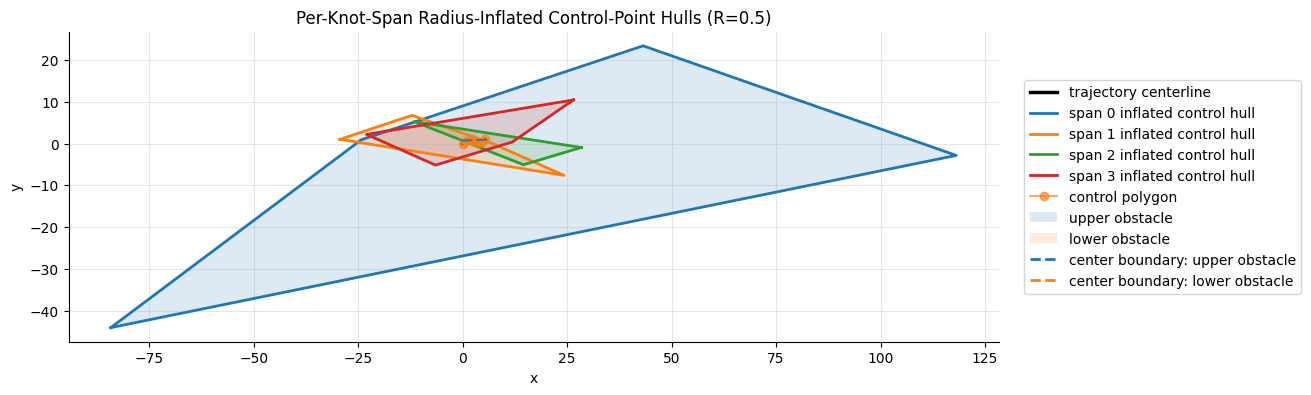

In [19]:
# 2D visualization of control-point hulls and radius-inflated control-polytope projections
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(curve_xy[:, 0], curve_xy[:, 1], color="black", linewidth=2.5, label="trajectory centerline")

span_colors = plt.get_cmap("tab10")
for span_number, data in span_control_hulls_2d.items():
    color = span_colors(span_number % 10)

    inflated_projection = span_inflated_control_polytopes[span_number]["projection"]
    closed_inflated = np.r_[inflated_projection, inflated_projection[:1]]
    ax.fill(closed_inflated[:, 0], closed_inflated[:, 1], color=color, alpha=0.15)
    ax.plot(closed_inflated[:, 0], closed_inflated[:, 1], color=color, linewidth=2, label=f"span {span_number} inflated control hull")

    local_hull = data["hull"]
    closed_center = np.r_[local_hull, local_hull[:1]]
    ax.plot(closed_center[:, 0], closed_center[:, 1], "--", color=color, alpha=0.70, linewidth=1.2)

ax.plot(control_points_xy[:, 0], control_points_xy[:, 1], "o-", color="tab:orange", alpha=0.65, label="control polygon")

for name, vertices in unsafe_sets.items():
    closed = np.r_[vertices, vertices[:1]]
    ax.fill(closed[:, 0], closed[:, 1], alpha=0.15, label=name)

for name, boundary in robot_center_boundaries.items():
    plot_boundary_2d(ax, boundary, x_limits=(-0.25, 5.8), label=f"center boundary: {name}")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Per-Knot-Span Radius-Inflated Control-Point Hulls (R={R})")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.show()


In [20]:
# 3D interactive visualization of radius-inflated control polytopes
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError:
    raise ImportError("Install plotly for 3D visualization")

if ConvexHull is None:
    raise ImportError("scipy is required for 3D convex hull.")

if "hull_edges_from_simplices" not in globals():
    def hull_edges_from_simplices(simplices):
        edges = set()
        for simplex in simplices:
            for local_i in range(len(simplex)):
                for local_j in range(local_i + 1, len(simplex)):
                    edges.add(tuple(sorted((int(simplex[local_i]), int(simplex[local_j])))))
        return sorted(edges)

span_colors_plotly = qualitative.Plotly
fig = go.Figure()

for span_number, inflated_data in sorted(span_inflated_control_polytopes.items()):
    color = span_colors_plotly[span_number % len(span_colors_plotly)]
    hull = inflated_data["hull"]
    points = inflated_data["points"]
    hi, hj, hk = hull.simplices.T

    label = f"span {span_number}: t=[{inflated_data['t_start']:.2f}, {inflated_data['t_end']:.2f}]"
    fig.add_trace(go.Mesh3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        i=hi,
        j=hj,
        k=hk,
        name=f"inflated control polytope {span_number}",
        color=color,
        opacity=0.30,
        flatshading=True,
        hovertemplate=label + "<extra></extra>",
    ))

    for edge_index, (a, b) in enumerate(hull_edges_from_simplices(hull.simplices)):
        edge = points[[a, b]]
        fig.add_trace(go.Scatter3d(
            x=edge[:, 0],
            y=edge[:, 1],
            z=edge[:, 2],
            mode="lines",
            line=dict(color=color, width=4),
            showlegend=False,
            hoverinfo="skip",
        ))

fig.add_trace(go.Scatter3d(
    x=curve_xyt[:, 0],
    y=curve_xyt[:, 1],
    z=curve_xyt[:, 2],
    mode="lines",
    line=dict(color="black", width=7),
    name="trajectory centerline",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    mode="lines+markers+text",
    line=dict(color="darkorange", width=3, dash="dash"),
    marker=dict(size=5, color="darkorange", line=dict(color="black", width=1)),
    text=[f"P{idx}" for idx in range(len(control_points_xyt))],
    textposition="top center",
    name="control polygon",
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title=f"Per-Knot-Span Radius-Inflated Control Polytopes (R={R})",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
    width=1200,
    height=900,
)
fig.show()

print(f"\nPer-knot-span inflated control-polytope statistics:")
print(f"  Total polytopes: {len(span_inflated_control_polytopes)}")
for span_number, inflated_data in sorted(span_inflated_control_polytopes.items()):
    hull = inflated_data["hull"]
    print(f"  Span {span_number}: {len(inflated_data['points'])} vertices, {len(hull.simplices)} hull faces, {len(inflated_data['halfspaces'])} shifted halfspaces")
print("  These polytopes are built from control-point hull halfspaces, not trajectory samples.")



Per-knot-span inflated control-polytope statistics:
  Total polytopes: 4
  Span 0: 4 vertices, 4 hull faces, 4 shifted halfspaces
  Span 1: 4 vertices, 4 hull faces, 4 shifted halfspaces
  Span 2: 4 vertices, 4 hull faces, 4 shifted halfspaces
  Span 3: 4 vertices, 4 hull faces, 4 shifted halfspaces
  These polytopes are built from control-point hull halfspaces, not trajectory samples.


## Robot Spatio-Temporal Footprint

Visualization of the swept volume (footprint) of the robot as it traverses the trajectory. The robot is modeled as a disk of radius R in the (x, y) plane, moving along the 3D space-time curve.

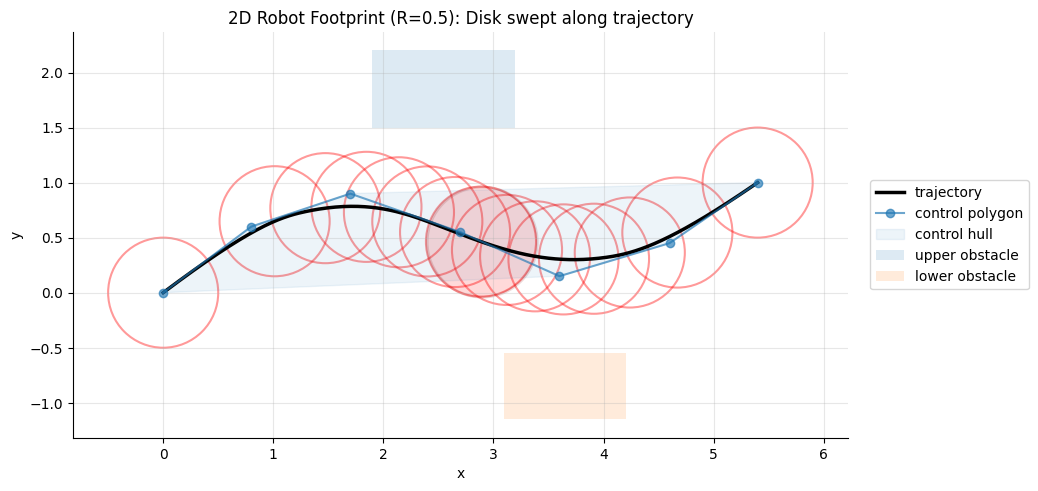

Robot footprint visualization:
  Robot radius R: 0.5
  Trajectory length (arc-length approximation): 5.85
  Time domain: t ∈ [0.0, 6.0]
  Footprint consists of a disk of radius 0.5 swept along the 3D trajectory


In [21]:
# 2D robot footprint visualization
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the trajectory
ax.plot(curve_xy[:, 0], curve_xy[:, 1], color="black", linewidth=2.5, label="trajectory")

# Sample points along trajectory and draw circles representing robot footprint
num_footprint_circles = 15
footprint_indices = np.linspace(0, len(curve_xy) - 1, num_footprint_circles, dtype=int)
for idx in footprint_indices:
    point = curve_xy[idx]
    circle = plt.Circle(point, R, fill=False, edgecolor="red", alpha=0.4, linewidth=1.5)
    ax.add_patch(circle)

# Add one filled circle for emphasis
emphasis_idx = len(curve_xy) // 2
emphasis_point = curve_xy[emphasis_idx]
circle_filled = plt.Circle(emphasis_point, R, fill=True, facecolor="red", edgecolor="darkred", alpha=0.15, linewidth=2)
ax.add_patch(circle_filled)

# Plot control points and hull
ax.plot(control_points_xy[:, 0], control_points_xy[:, 1], "o-", color="tab:blue", alpha=0.65, label="control polygon")
hull_closed = np.r_[safe_hull_xy, safe_hull_xy[:1]]
ax.fill(hull_closed[:, 0], hull_closed[:, 1], color="tab:blue", alpha=0.08, label="control hull")

# Plot unsafe regions
for name, vertices in unsafe_sets.items():
    closed = np.r_[vertices, vertices[:1]]
    ax.fill(closed[:, 0], closed[:, 1], alpha=0.15, label=name)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"2D Robot Footprint (R={R}): Disk swept along trajectory")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.show()

# 3D spatio-temporal footprint
try:
    import plotly.graph_objects as go
except ImportError:
    raise ImportError("Install plotly for 3D visualization")

# Create tube-like surface by rotating a point at distance R around the trajectory
num_samples = len(curve_xyt)
num_angles = 16
angles = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)

# Build mesh: for each point on trajectory, create a circle of points at distance R
tube_x = []
tube_y = []
tube_z = []

for i in range(num_samples):
    t_point = curve_xyt[i]
    x_c, y_c, t_c = t_point
    
    # Create circle perpendicular to trajectory (in xy-plane at this time)
    for angle in angles:
        x = x_c + R * np.cos(angle)
        y = y_c + R * np.sin(angle)
        tube_x.append(x)
        tube_y.append(y)
        tube_z.append(t_c)

tube_x = np.array(tube_x).reshape(num_samples, num_angles)
tube_y = np.array(tube_y).reshape(num_samples, num_angles)
tube_z = np.array(tube_z).reshape(num_samples, num_angles)

fig = go.Figure()

# Add the swept tube surface
fig.add_trace(go.Surface(
    x=tube_x,
    y=tube_y,
    z=tube_z,
    colorscale="Reds",
    opacity=0.5,
    name="robot footprint",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

# Add trajectory
fig.add_trace(go.Scatter3d(
    x=curve_xyt[:, 0],
    y=curve_xyt[:, 1],
    z=curve_xyt[:, 2],
    mode="lines",
    line=dict(color="black", width=6),
    name="trajectory",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

# Add radius-adjusted centerline safety boundaries (as surfaces)
for name, boundary in robot_center_boundaries.items():
    normal = boundary.normal
    xs = np.linspace(-0.5, 6.0, 15)
    zs = np.linspace(t0, tf, 15)
    X, Z = np.meshgrid(xs, zs)
    if abs(normal[1]) > 1e-9:
        Y = (boundary.offset - normal[0] * X) / normal[1]
        fig.add_trace(go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Greens",
            opacity=0.15,
            name=f"center boundary: {name}",
            showscale=False,
            hovertemplate=f"{name}<br>x=%{{x:.2f}}<br>y=%{{y:.2f}}<br>t=%{{z:.2f}}<extra></extra>",
        ))

fig.update_layout(
    title=f"Robot Spatio-Temporal Footprint (R={R}) with Radius-Adjusted Boundaries",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

print(f"Robot footprint visualization:")
print(f"  Robot radius R: {R}")
print(f"  Trajectory length (arc-length approximation): {np.sum(np.linalg.norm(np.diff(curve_xy, axis=0), axis=1)):.2f}")
print(f"  Time domain: t ∈ [{t0}, {tf}]")
print(f"  Footprint consists of a disk of radius {R} swept along the 3D trajectory")


In [22]:
# Combined visualization: footprint + radius-inflated control polytopes
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError:
    raise ImportError("Install plotly for 3D visualization")

num_samples = len(curve_xyt)
num_angles = 12
angles = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)

tube_x = []
tube_y = []
tube_z = []

for i in range(num_samples):
    x_c, y_c, t_c = curve_xyt[i]
    for angle in angles:
        tube_x.append(x_c + R * np.cos(angle))
        tube_y.append(y_c + R * np.sin(angle))
        tube_z.append(t_c)

tube_x = np.array(tube_x).reshape(num_samples, num_angles)
tube_y = np.array(tube_y).reshape(num_samples, num_angles)
tube_z = np.array(tube_z).reshape(num_samples, num_angles)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=tube_x,
    y=tube_y,
    z=tube_z,
    colorscale="Reds",
    opacity=0.35,
    name="sampled robot footprint",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

span_colors_plotly = qualitative.Plotly
for span_number, inflated_data in sorted(span_inflated_control_polytopes.items()):
    color = span_colors_plotly[span_number % len(span_colors_plotly)]
    hull = inflated_data["hull"]
    points = inflated_data["points"]
    hi, hj, hk = hull.simplices.T
    fig.add_trace(go.Mesh3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        i=hi,
        j=hj,
        k=hk,
        name=f"inflated control polytope {span_number}",
        color=color,
        opacity=0.24,
        flatshading=True,
        hovertemplate=f"span {span_number}<extra></extra>",
    ))

fig.add_trace(go.Scatter3d(
    x=curve_xyt[:, 0],
    y=curve_xyt[:, 1],
    z=curve_xyt[:, 2],
    mode="lines",
    line=dict(color="black", width=6),
    name="trajectory centerline",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    mode="lines+markers",
    line=dict(color="darkorange", width=3, dash="dash"),
    marker=dict(size=5, color="darkorange", line=dict(color="black", width=1)),
    name="control polygon",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title=f"Robot Footprint (red) vs Radius-Inflated Control Polytopes (R={R})",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
    width=1000,
    height=800,
)
fig.show()

print("Comparison of sampled robot footprint and inflated control polytopes:")
print(f"  Robot radius R: {R}")
print(f"  Inflated control polytopes: {len(span_inflated_control_polytopes)}")
print("  Polytopes are built from shifted control-point hull halfspaces; the red footprint is only a visual overlay.")


Comparison of sampled robot footprint and inflated control polytopes:
  Robot radius R: 0.5
  Inflated control polytopes: 4
  Polytopes are built from shifted control-point hull halfspaces; the red footprint is only a visual overlay.


## Square Robot Footprint Reservation

Assume the robot footprint is an axis-aligned square with side length `2R`. Each per-knot control-point polytope is inflated by the square footprint using control points only. The red footprint overlay is for visualization.


In [23]:
# Square robot footprint: side length 2R, half side R.
square_half_side = R
square_side_length = 2.0 * R
square_offsets_xy = np.array([
    [-square_half_side, -square_half_side],
    [ square_half_side, -square_half_side],
    [ square_half_side,  square_half_side],
    [-square_half_side,  square_half_side],
])
square_offsets_xyt = np.c_[square_offsets_xy, np.zeros(len(square_offsets_xy))]


def inflate_control_polytope_by_square_footprint(points_xyt, square_offsets_xyt):
    """Inflate a control-point xyt polytope by an axis-aligned square footprint.

    This constructs
        Conv(control_points_xyt) + Conv(square_offsets_xyt)
    using the vertex-sum identity for Minkowski sums of convex polytopes:
        P + Q = Conv({p_i + q_j}).

    The result is still a convex polytope and `hull.equations` gives the
    halfspace representation for space-time segmentation.
    """
    points_xyt = np.asarray(points_xyt, dtype=float)
    footprint_offsets = np.asarray(square_offsets_xyt, dtype=float)
    sum_points = (points_xyt[:, None, :] + footprint_offsets[None, :, :]).reshape(-1, 3)
    try:
        hull = ConvexHull(sum_points)
    except Exception:
        hull = ConvexHull(sum_points, qhull_options="QJ")
    return sum_points, hull


local_knot_spans = knot_span_control_point_indices(knots, degree)
span_square_inflated_polytopes = {}

for span_number, span in enumerate(local_knot_spans):
    active_indices = span["indices"]
    active_points_xyt = control_points_xyt[active_indices]
    inflated_points, inflated_hull = inflate_control_polytope_by_square_footprint(
        active_points_xyt,
        square_offsets_xyt,
    )
    span_square_inflated_polytopes[span_number] = {
        "points": inflated_points,
        "hull": inflated_hull,
        "halfspaces": inflated_hull.equations,
        "t_start": span["t_start"],
        "t_end": span["t_end"],
        "indices": active_indices,
    }

print(f"Square robot side length: {square_side_length}")
print(f"Square robot half side: {square_half_side}")
print(f"Computed {len(span_square_inflated_polytopes)} square-inflated per-knot control polytopes")
for span_number, data in sorted(span_square_inflated_polytopes.items()):
    print(f"  Span {span_number}: active points {data['indices']}, "
          f"candidate vertices={len(data['points'])}, hull faces={len(data['hull'].simplices)}, "
          f"halfspaces={len(data['halfspaces'])}")


# 3D visualization: actual square footprint overlay + square-inflated control polytopes.
try:
    import plotly.graph_objects as go
    from plotly.colors import qualitative
except ImportError:
    raise ImportError("Install plotly for 3D visualization")

if "hull_edges_from_simplices" not in globals():
    def hull_edges_from_simplices(simplices):
        edges = set()
        for simplex in simplices:
            for local_i in range(len(simplex)):
                for local_j in range(local_i + 1, len(simplex)):
                    edges.add(tuple(sorted((int(simplex[local_i]), int(simplex[local_j])))))
        return sorted(edges)

# Draw a swept square tube around the evaluated trajectory as a visual overlay.
# This overlay samples the curve only for display; the inflated polytopes above
# are constructed from control points only.
num_footprint_samples = len(curve_xyt)
square_loop_offsets = np.vstack([square_offsets_xyt, square_offsets_xyt[:1]])
footprint_x = []
footprint_y = []
footprint_z = []
for center in curve_xyt:
    loop = center + square_loop_offsets
    footprint_x.append(loop[:, 0])
    footprint_y.append(loop[:, 1])
    footprint_z.append(loop[:, 2])
footprint_x = np.asarray(footprint_x)
footprint_y = np.asarray(footprint_y)
footprint_z = np.asarray(footprint_z)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=footprint_x,
    y=footprint_y,
    z=footprint_z,
    colorscale="Reds",
    opacity=0.36,
    showscale=False,
    name="square footprint",
    hovertemplate="square footprint<extra></extra>",
))

span_colors_plotly = qualitative.Plotly
for span_number, data in sorted(span_square_inflated_polytopes.items()):
    color = span_colors_plotly[span_number % len(span_colors_plotly)]
    points = data["points"]
    hull = data["hull"]
    hi, hj, hk = hull.simplices.T
    fig.add_trace(go.Mesh3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        i=hi,
        j=hj,
        k=hk,
        name=f"square-inflated polytope {span_number}",
        color=color,
        opacity=0.28,
        flatshading=True,
        hovertemplate=f"span {span_number}<br>side={square_side_length:.2f}<extra></extra>",
    ))
    for edge_index, (a, b) in enumerate(hull_edges_from_simplices(hull.simplices)):
        edge = points[[a, b]]
        fig.add_trace(go.Scatter3d(
            x=edge[:, 0],
            y=edge[:, 1],
            z=edge[:, 2],
            mode="lines",
            line=dict(color=color, width=4),
            showlegend=False,
            hoverinfo="skip",
        ))

fig.add_trace(go.Scatter3d(
    x=curve_xyt[:, 0],
    y=curve_xyt[:, 1],
    z=curve_xyt[:, 2],
    mode="lines",
    line=dict(color="black", width=6),
    name="trajectory centerline",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.add_trace(go.Scatter3d(
    x=control_points_xyt[:, 0],
    y=control_points_xyt[:, 1],
    z=control_points_xyt[:, 2],
    mode="lines+markers",
    line=dict(color="darkorange", width=3, dash="dash"),
    marker=dict(size=5, color="darkorange", line=dict(color="black", width=1)),
    name="control polygon",
    hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>t=%{z:.2f}<extra></extra>",
))

fig.update_layout(
    title=f"Square Footprint and Per-Knot Square-Inflated Control Polytopes (side={square_side_length:.2f})",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="t",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=42),
    legend=dict(x=0.02, y=0.98),
    width=1200,
    height=900,
)
fig.show()


Square robot side length: 1.0
Square robot half side: 0.5
Computed 4 square-inflated per-knot control polytopes
  Span 0: active points [0 1 2 3], candidate vertices=16, hull faces=24, halfspaces=24
  Span 1: active points [1 2 3 4], candidate vertices=16, hull faces=24, halfspaces=24
  Span 2: active points [2 3 4 5], candidate vertices=16, hull faces=20, halfspaces=20
  Span 3: active points [3 4 5 6], candidate vertices=16, hull faces=24, halfspaces=24
